In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the AAPL dataset
df = pd.read_csv("data/AAPL.csv")

print("Complete dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())


Complete dataset shape: (10931, 7)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [25]:
# Select the last 500 consecutive observations
data = df.tail(500).copy().reset_index(drop=True)

# Trading-day index
x = np.arange(1, 501, dtype=float)

# Closing prices
y = data["Close"].to_numpy(dtype=float)

print("Number of selected observations:", len(data))
print("Date range:", data["Date"].iloc[0], "to", data["Date"].iloc[-1])

print("\nFirst 5 observations:")
print(data[["Date", "Close"]].head())

print("\nLast 5 observations:")
print(data[["Date", "Close"]].tail())


Number of selected observations: 500
Date range: 2022-04-27 to 2024-04-23

First 5 observations:
         Date       Close
0  2022-04-27  156.570007
1  2022-04-28  163.639999
2  2022-04-29  157.649994
3  2022-05-02  157.960007
4  2022-05-03  159.479996

Last 5 observations:
           Date       Close
495  2024-04-17  168.000000
496  2024-04-18  167.039993
497  2024-04-19  165.000000
498  2024-04-22  165.839996
499  2024-04-23  166.899994


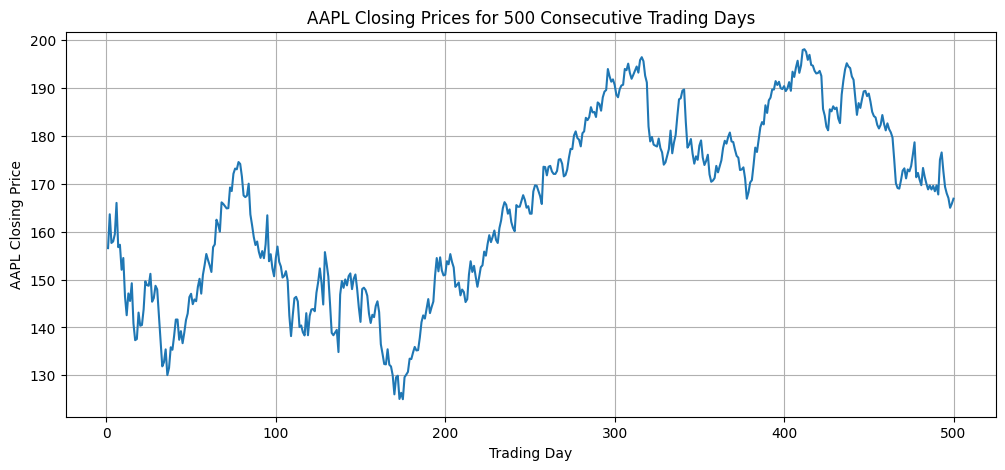

In [26]:
# Plot the original 500-day stock-price series
plt.figure(figsize=(12, 5))
plt.plot(x, y)
plt.xlabel("Trading Day")
plt.ylabel("AAPL Closing Price")
plt.title("AAPL Closing Prices for 500 Consecutive Trading Days")
plt.grid()
plt.show()


In [27]:
def numerical_lagrange(x_data, y_data, x_val):
    n = len(x_data)
    total_p = 0.0

    for i in range(n):
        li = 1.0

        for j in range(n):
            if j != i:
                li *= (x_val - x_data[j]) / (x_data[i] - x_data[j])

        total_p += y_data[i] * li

    return total_p


In [28]:
test_indices = [0, 1, 249, 499]

for i in test_indices:
    estimated = numerical_lagrange(x, y, x[i])
    error = abs(estimated - y[i])

    print(
        f"x = {x[i]:.0f}, "
        f"actual = {y[i]:.6f}, "
        f"interpolated = {estimated:.6f}, "
        f"absolute error = {error:.3e}"
    )


x = 1, actual = 156.570007, interpolated = 156.570007, absolute error = 0.000e+00
x = 2, actual = 163.639999, interpolated = 163.639999, absolute error = 0.000e+00
x = 250, actual = 163.770004, interpolated = 163.770004, absolute error = 0.000e+00
x = 500, actual = 166.899994, interpolated = 166.899994, absolute error = 0.000e+00


In [29]:
node_counts = [5, 10, 20, 50, 100, 250, 500]

# A moderate evaluation grid keeps the direct implementation practical.
x_plot = np.linspace(1, 500, 251)

interpolated_results = {}
timings = {}

for n in node_counts:
    # Select n equally spaced nodes from the 500 observations
    indices = np.linspace(0, 499, n, dtype=int)

    x_nodes = x[indices]
    y_nodes = y[indices]

    # Evaluate the Lagrange polynomial over the plotting grid
    start = __import__("time").perf_counter()

    y_interp = np.array([
        numerical_lagrange(x_nodes, y_nodes, x_val)
        for x_val in x_plot
    ])

    elapsed = __import__("time").perf_counter() - start

    interpolated_results[n] = y_interp
    timings[n] = elapsed

    print(
        f"n = {n:3d}, "
        f"degree <= {n-1:3d}, "
        f"time = {elapsed:.6f} s"
    )


n =   5, degree <=   4, time = 0.002232 s
n =  10, degree <=   9, time = 0.007650 s
n =  20, degree <=  19, time = 0.031017 s
n =  50, degree <=  49, time = 0.117397 s
n = 100, degree <=  99, time = 0.460057 s
n = 250, degree <= 249, time = 3.016739 s
n = 500, degree <= 499, time = 12.045323 s


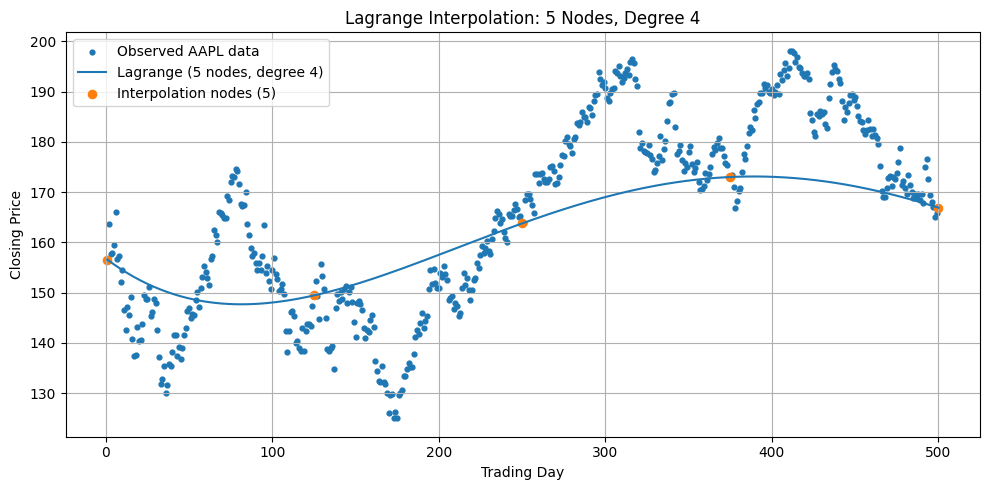

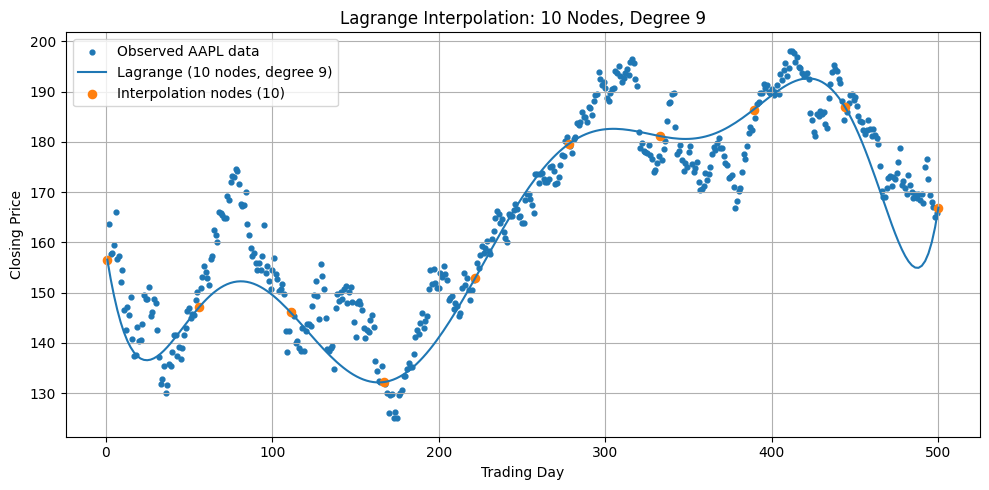

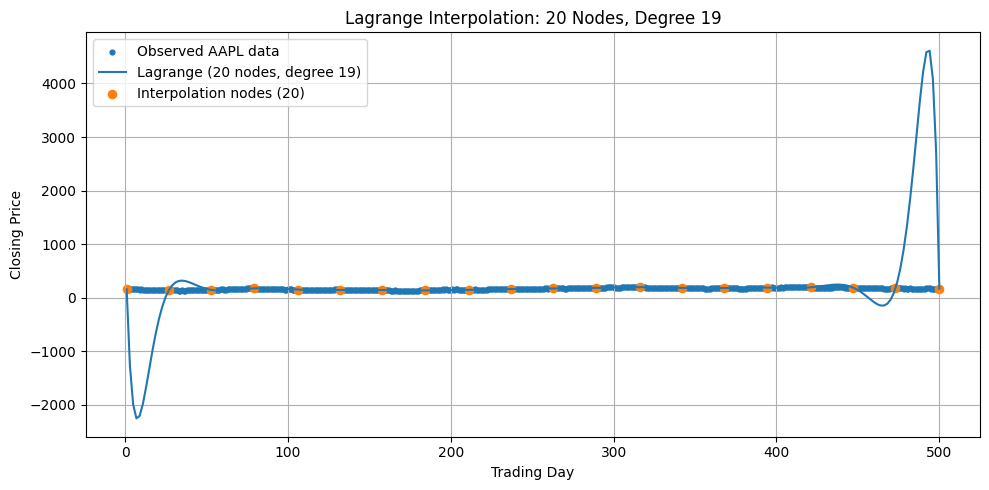

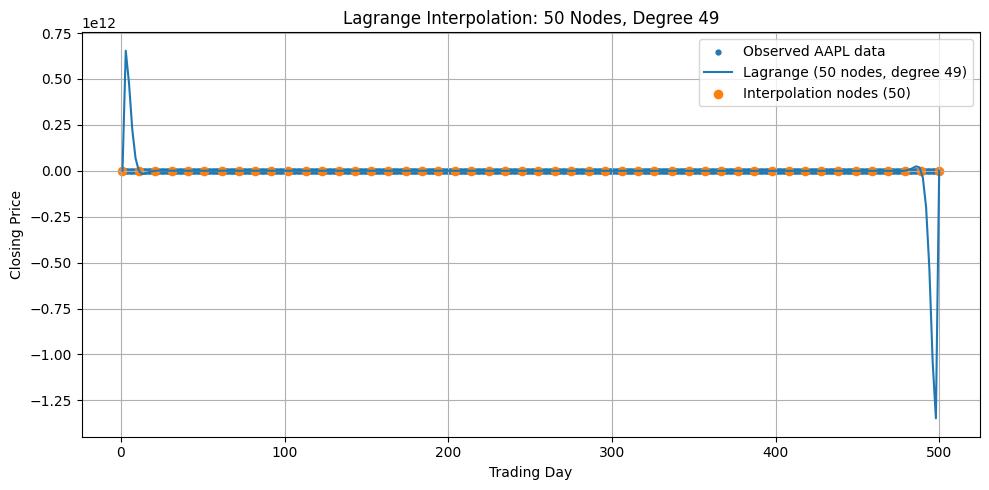

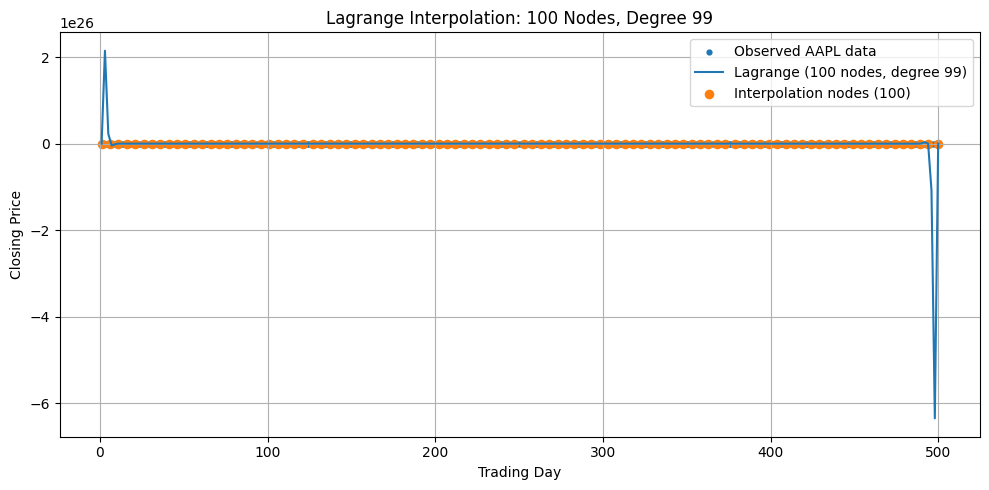

In [39]:
plot_nodes = [5, 10, 20, 50, 100]

for n in plot_nodes:

    plt.figure(figsize=(10, 5))

    # Actual observed data points
    plt.scatter(
        x,
        y,
        label="Observed AAPL data",
        s=12
    )

    # Lagrange interpolating polynomial
    plt.plot(
        x_plot,
        interpolated_results[n],
        label=f"Lagrange ({n} nodes, degree {n-1})",
        linewidth=1.5
    )

    # Mark the actual interpolation nodes
    indices = np.linspace(0, 499, n, dtype=int)

    plt.scatter(
        x[indices],
        y[indices],
        s=35,
        label=f"Interpolation nodes ({n})"
    )

    plt.title(f"Lagrange Interpolation: {n} Nodes, Degree {n-1}")
    plt.xlabel("Trading Day")
    plt.ylabel("Closing Price")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

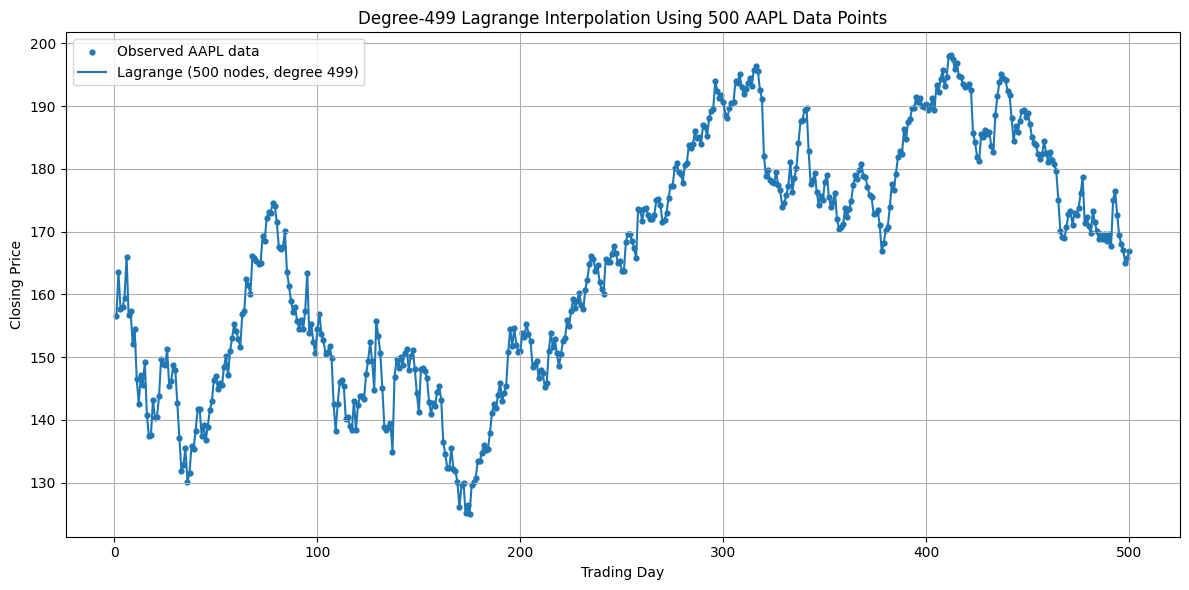

In [40]:
def numerical_lagrange(x_data, y_data, x_val):
    n = len(x_data)
    total_p = 0.0

    for i in range(n):
        li = 1.0

        for j in range(n):
            if j != i:
                li *= (x_val - x_data[j]) / (x_data[i] - x_data[j])

        total_p += y_data[i] * li

    return total_p

x_nodes = x
y_nodes = y
y_lagrange_500 = np.array([
    numerical_lagrange(x_nodes, y_nodes, x_val)
    for x_val in x
])
plt.figure(figsize=(12, 6))

plt.scatter(
    x,
    y,
    s=12,
    label="Observed AAPL data"
)

plt.plot(
    x,
    y_lagrange_500,
    linewidth=1.5,
    label="Lagrange (500 nodes, degree 499)"
)

plt.xlabel("Trading Day")
plt.ylabel("Closing Price")
plt.title("Degree-499 Lagrange Interpolation Using 500 AAPL Data Points")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [42]:
for n in [5, 10, 20, 50, 100, 250, 500]:

    indices = np.linspace(0, 499, n, dtype=int)

    x_nodes = x[indices]
    y_nodes = y[indices]

    errors = []

    for xi, yi in zip(x_nodes, y_nodes):
        p = numerical_lagrange(x_nodes, y_nodes, xi)
        errors.append(abs(p - yi))

    print(
        f"n = {n:3d}, "
        f"degree = {n-1:3d}, "
        f"maximum node error = {max(errors):.6e}"
    )

n =   5, degree =   4, maximum node error = 0.000000e+00
n =  10, degree =   9, maximum node error = 0.000000e+00
n =  20, degree =  19, maximum node error = 0.000000e+00
n =  50, degree =  49, maximum node error = 0.000000e+00
n = 100, degree =  99, maximum node error = 0.000000e+00
n = 250, degree = 249, maximum node error = 0.000000e+00
n = 500, degree = 499, maximum node error = 0.000000e+00


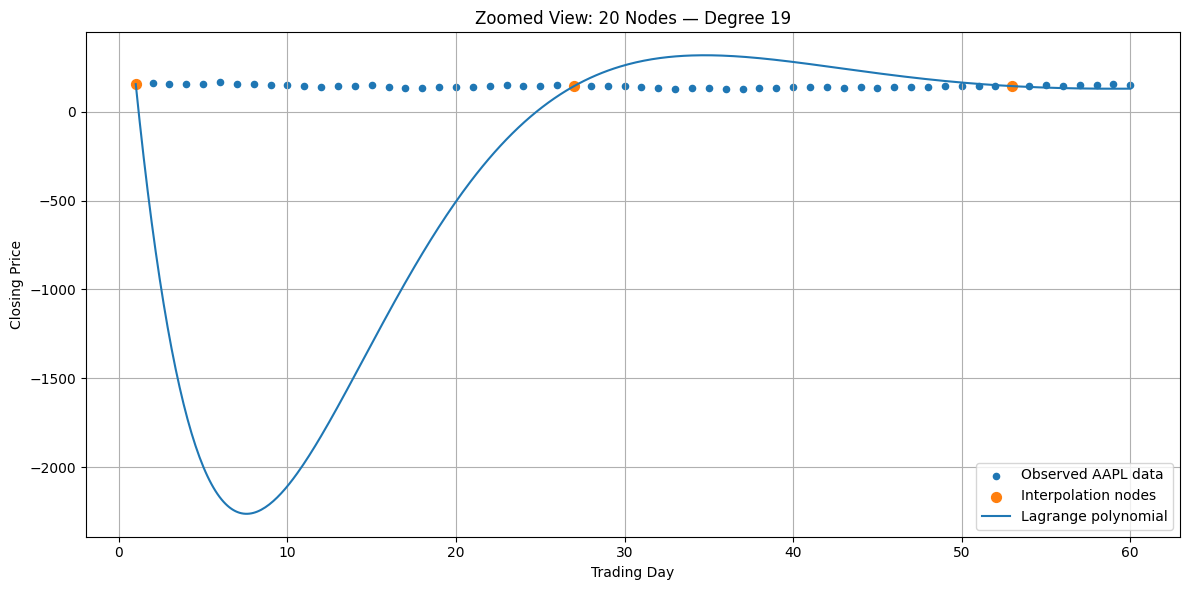

In [43]:
n = 20

indices = np.linspace(0, 499, n, dtype=int)

x_nodes = x[indices]
y_nodes = y[indices]

# Dense x values for a smooth polynomial curve
x_zoom = np.linspace(1, 60, 500)

y_zoom = np.array([
    numerical_lagrange(x_nodes, y_nodes, xv)
    for xv in x_zoom
])

plt.figure(figsize=(12, 6))

# All observed data in the region
mask = (x >= 1) & (x <= 60)

plt.scatter(
    x[mask],
    y[mask],
    s=20,
    label="Observed AAPL data"
)

# Interpolation nodes in the region
node_mask = (x_nodes >= 1) & (x_nodes <= 60)

plt.scatter(
    x_nodes[node_mask],
    y_nodes[node_mask],
    s=50,
    label="Interpolation nodes"
)

# Lagrange polynomial
plt.plot(
    x_zoom,
    y_zoom,
    linewidth=1.5,
    label="Lagrange polynomial"
)

plt.xlabel("Trading Day")
plt.ylabel("Closing Price")
plt.title("Zoomed View: 20 Nodes — Degree 19")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

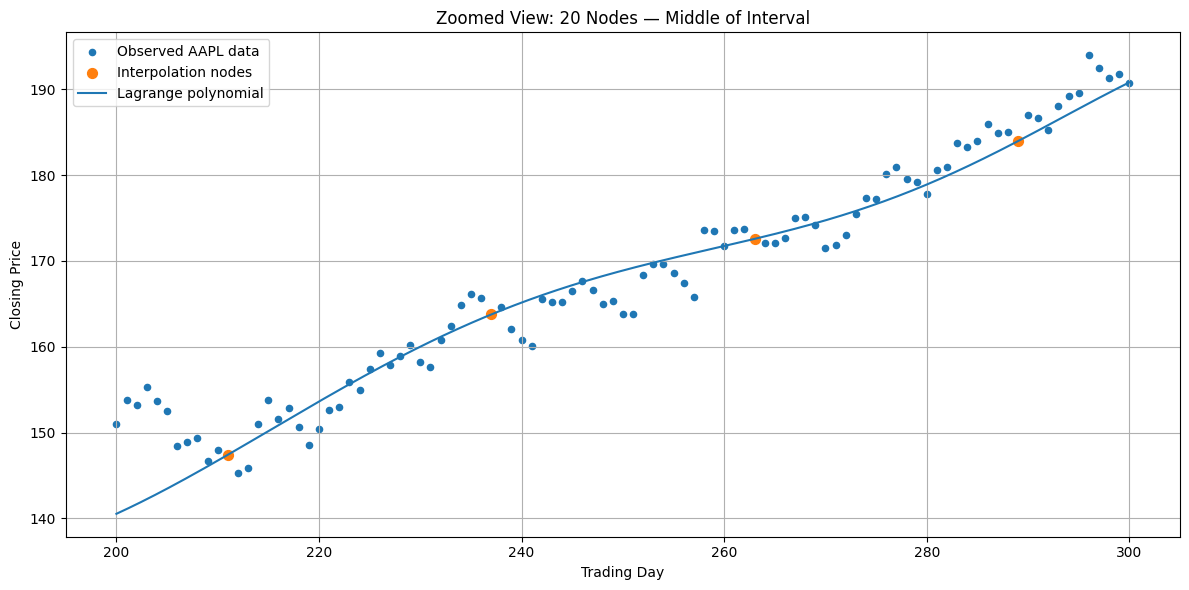

In [44]:
n = 20

indices = np.linspace(0, 499, n, dtype=int)

x_nodes = x[indices]
y_nodes = y[indices]

x_zoom = np.linspace(200, 300, 500)

y_zoom = np.array([
    numerical_lagrange(x_nodes, y_nodes, xv)
    for xv in x_zoom
])

plt.figure(figsize=(12, 6))

mask = (x >= 200) & (x <= 300)

plt.scatter(
    x[mask],
    y[mask],
    s=20,
    label="Observed AAPL data"
)

node_mask = (x_nodes >= 200) & (x_nodes <= 300)

plt.scatter(
    x_nodes[node_mask],
    y_nodes[node_mask],
    s=50,
    label="Interpolation nodes"
)

plt.plot(
    x_zoom,
    y_zoom,
    linewidth=1.5,
    label="Lagrange polynomial"
)

plt.xlabel("Trading Day")
plt.ylabel("Closing Price")
plt.title("Zoomed View: 20 Nodes — Middle of Interval")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [47]:
def zoom_lagrange(n, start_day, end_day):

    indices = np.linspace(0, 499, n, dtype=int)

    x_nodes = x[indices]
    y_nodes = y[indices]

    x_zoom = np.linspace(start_day, end_day, 500)

    y_zoom = np.array([
        numerical_lagrange(x_nodes, y_nodes, xv)
        for xv in x_zoom
    ])

    plt.figure(figsize=(12, 6))

    # Observed data
    mask = (x >= start_day) & (x <= end_day)

    plt.scatter(
        x[mask],
        y[mask],
        s=20,
        label="Observed AAPL data"
    )

    # Interpolation nodes
    node_mask = (
        (x_nodes >= start_day) &
        (x_nodes <= end_day)
    )

    plt.scatter(
        x_nodes[node_mask],
        y_nodes[node_mask],
        s=50,
        label="Interpolation nodes"
    )

    # Polynomial
    plt.plot(
        x_zoom,
        y_zoom,
        linewidth=1.5,
        label=f"Lagrange ({n} nodes, degree {n-1})"
    )

    plt.xlabel("Trading Day")
    plt.ylabel("Closing Price")

    plt.title(
        f"Zoomed Lagrange Interpolation: "
        f"{n} Nodes — Degree {n-1}"
    )

    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

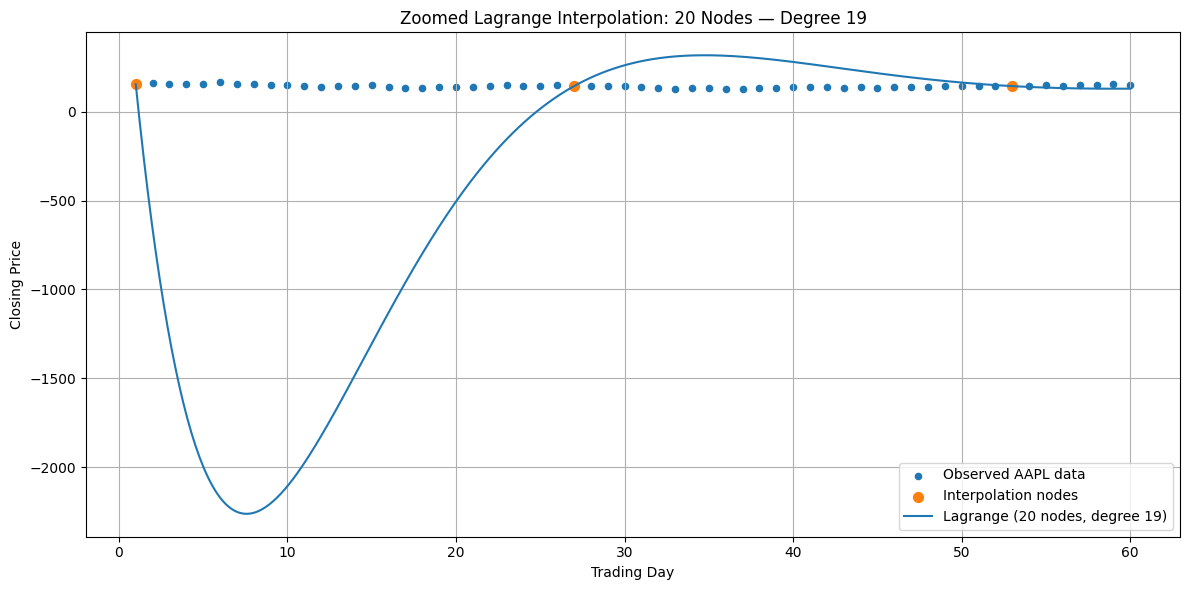

In [49]:
zoom_lagrange(20, 1, 60)

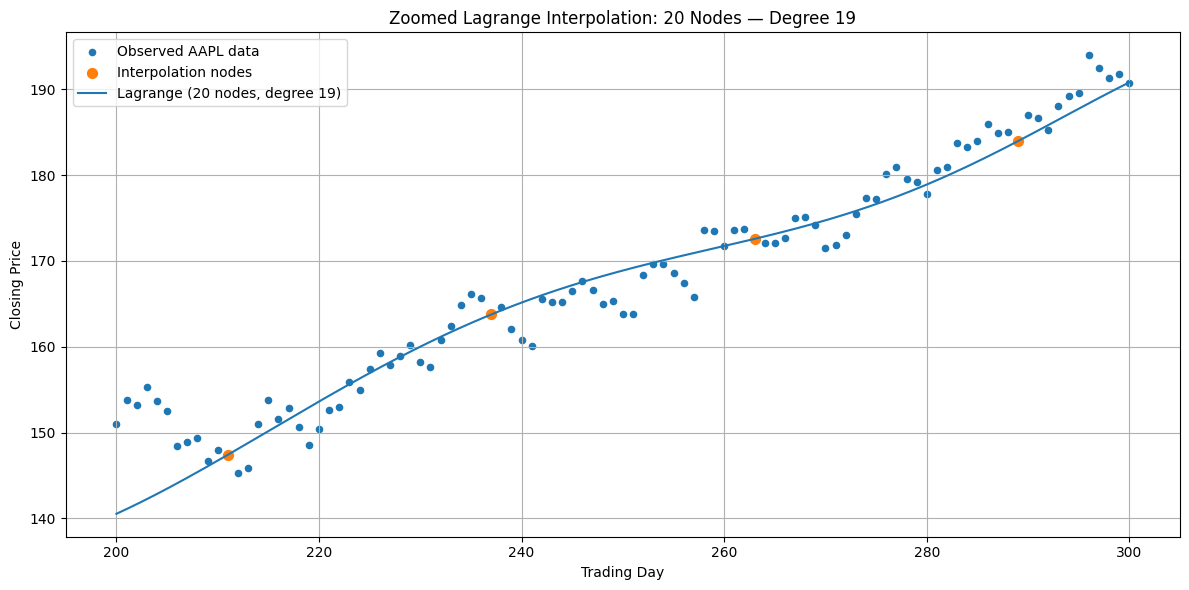

In [50]:
zoom_lagrange(20, 200, 300)

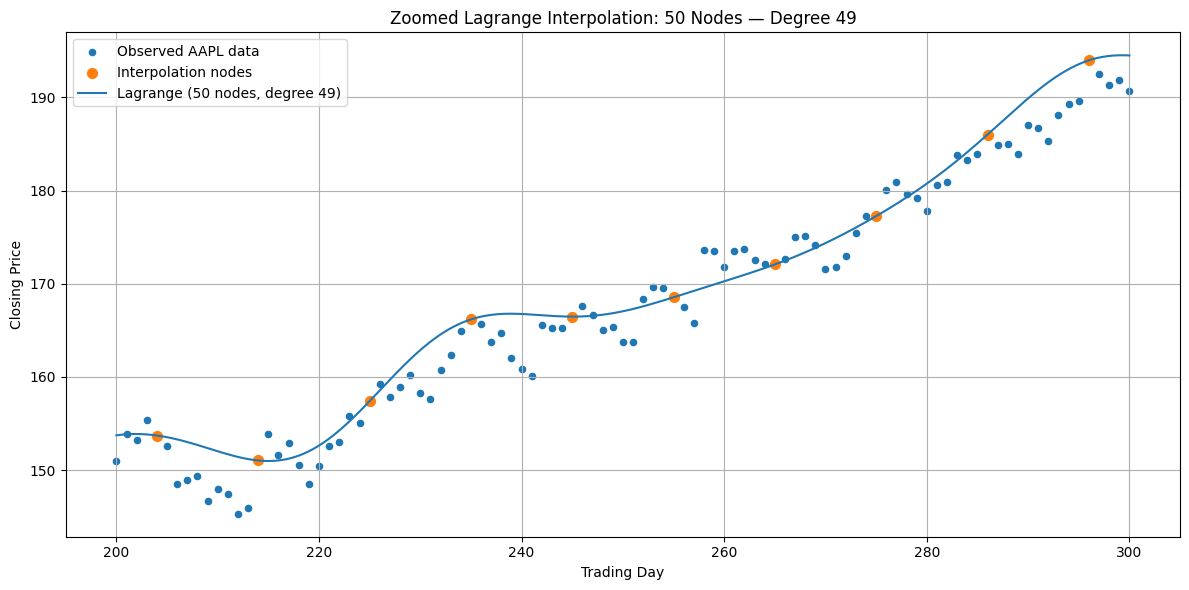

In [51]:
zoom_lagrange(50, 200, 300)

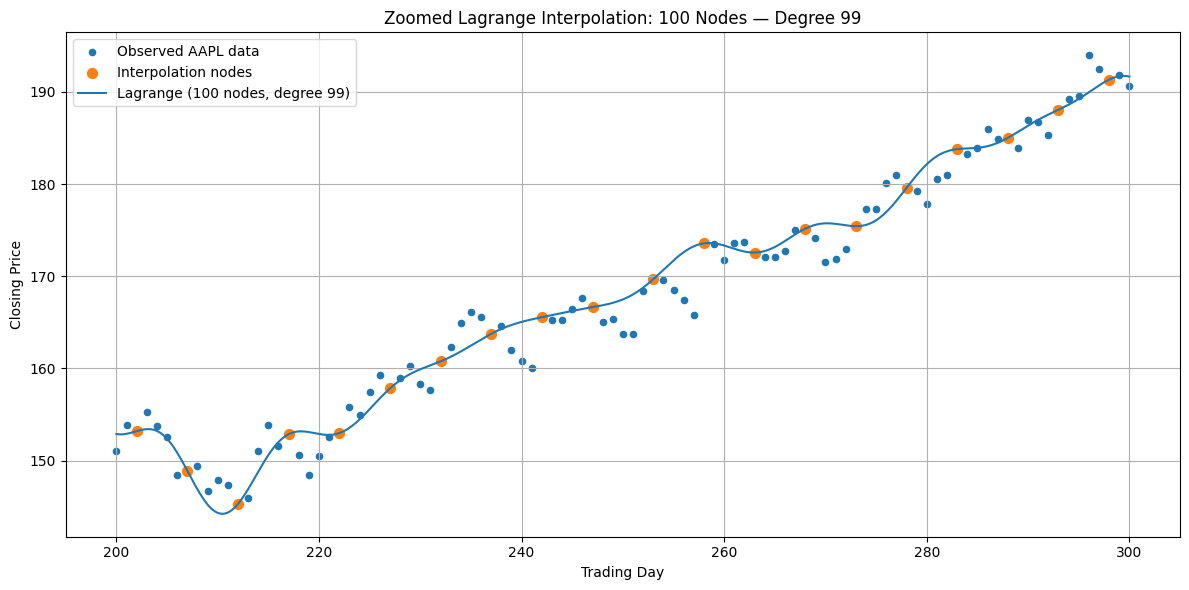

In [52]:
zoom_lagrange(100, 200, 300)

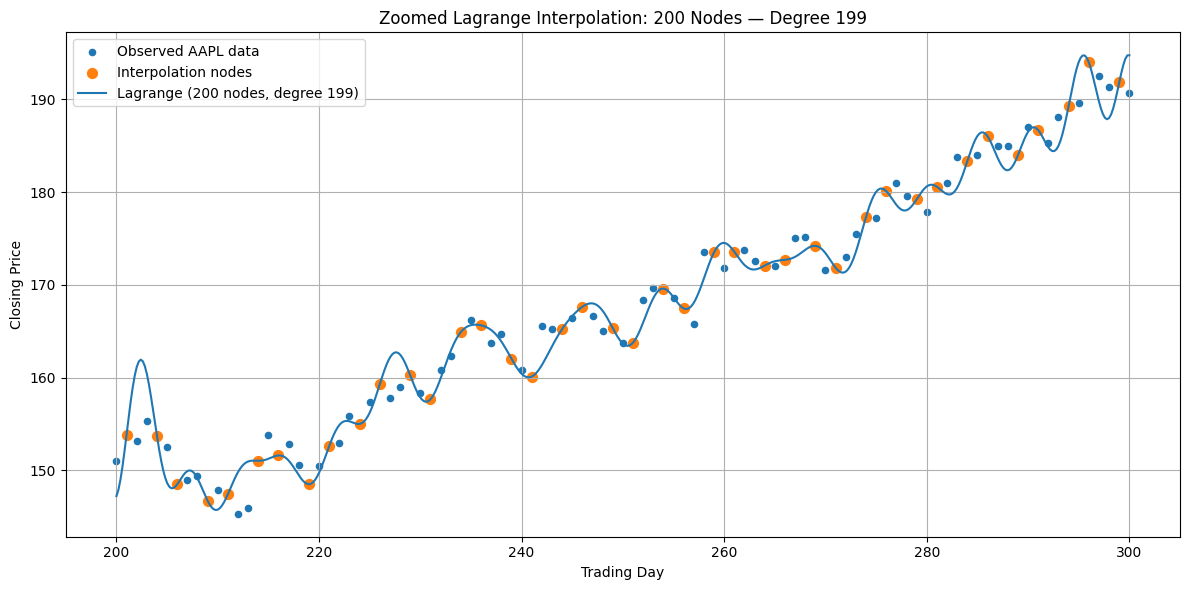

In [53]:
zoom_lagrange(200, 200, 300)

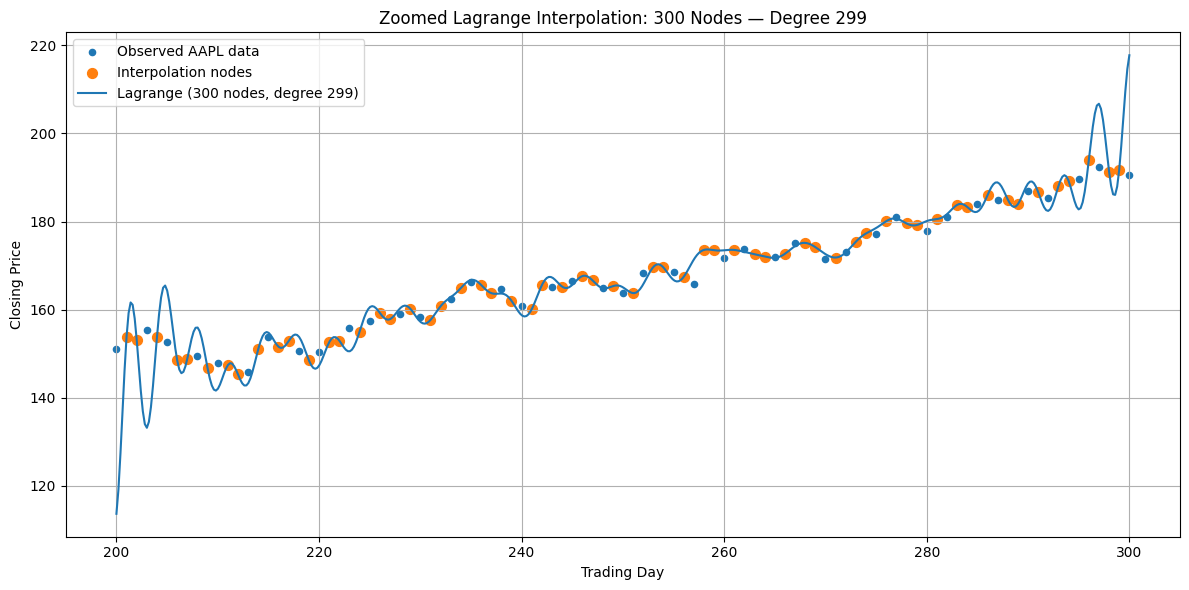

In [56]:
zoom_lagrange(300, 200, 300)

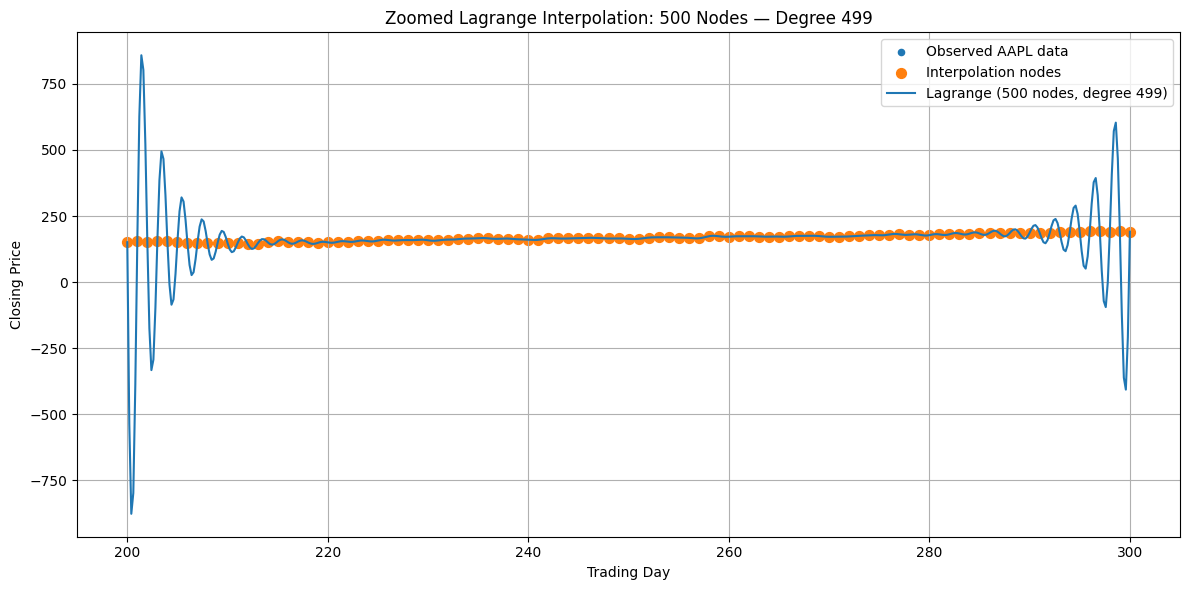

In [57]:
zoom_lagrange(500, 200, 300)

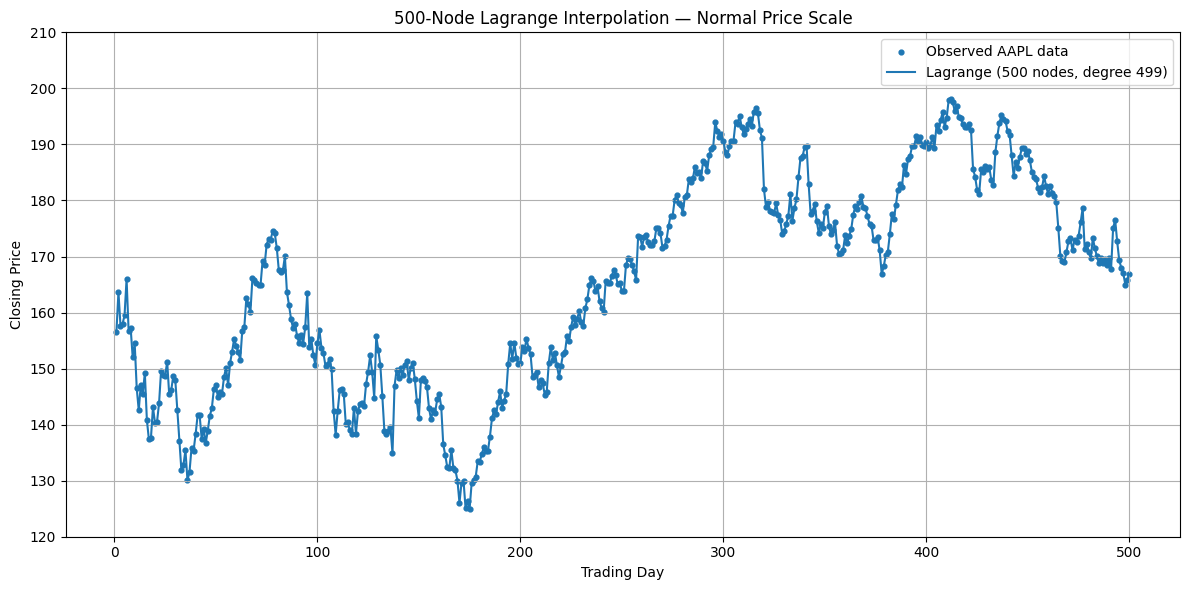

In [41]:
plt.figure(figsize=(12, 6))

# Actual observed stock prices
plt.scatter(
    x,
    y,
    s=12,
    label="Observed AAPL data"
)

# Degree-499 Lagrange polynomial
plt.plot(
    x,
    y_lagrange_500,
    linewidth=1.5,
    label="Lagrange (500 nodes, degree 499)"
)

plt.ylim(120, 210)

plt.xlabel("Trading Day")
plt.ylabel("Closing Price")
plt.title("500-Node Lagrange Interpolation — Normal Price Scale")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [59]:
errors = np.abs(y_lagrange_500 - y)

print("Maximum error:", np.max(errors))
print("Mean error:", np.mean(errors))

Maximum error: 0.0
Mean error: 0.0


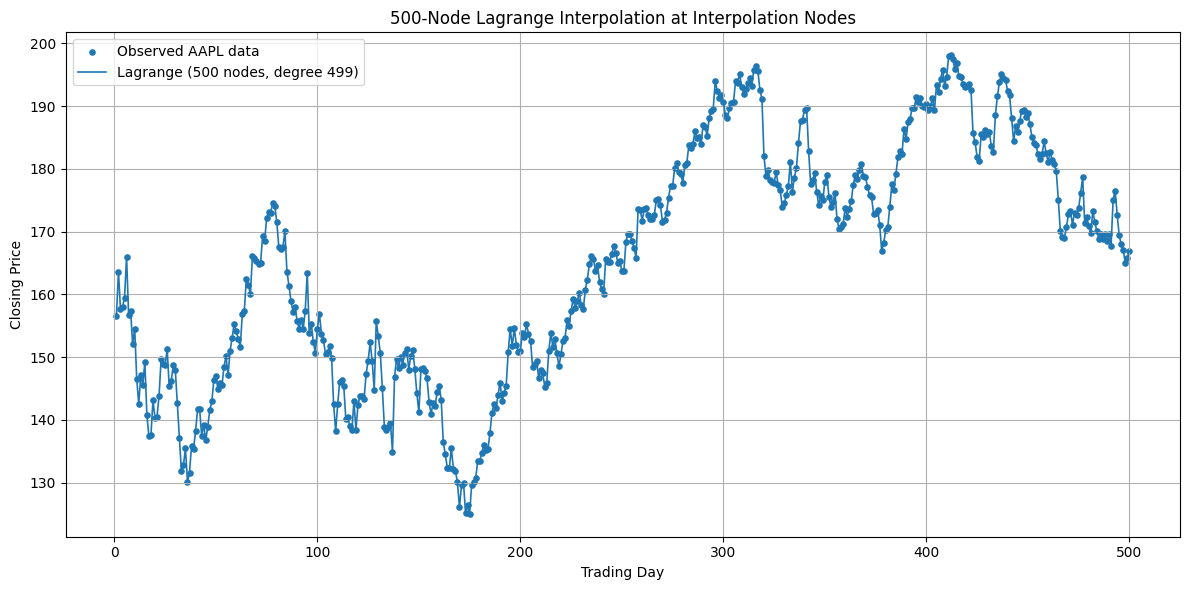

In [58]:
# Use all 500 observations as interpolation nodes
x_nodes = x
y_nodes = y

# Evaluate the Lagrange polynomial at all interpolation nodes
y_lagrange_500 = np.array([
    numerical_lagrange(x_nodes, y_nodes, x_val)
    for x_val in x_nodes
])

plt.figure(figsize=(12, 6))

# Observed data points
plt.scatter(
    x,
    y,
    s=14,
    label="Observed AAPL data"
)

# Lagrange values at the nodes
plt.plot(
    x_nodes,
    y_lagrange_500,
    linewidth=1.2,
    label="Lagrange (500 nodes, degree 499)"
)

plt.xlabel("Trading Day")
plt.ylabel("Closing Price")
plt.title("500-Node Lagrange Interpolation at Interpolation Nodes")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

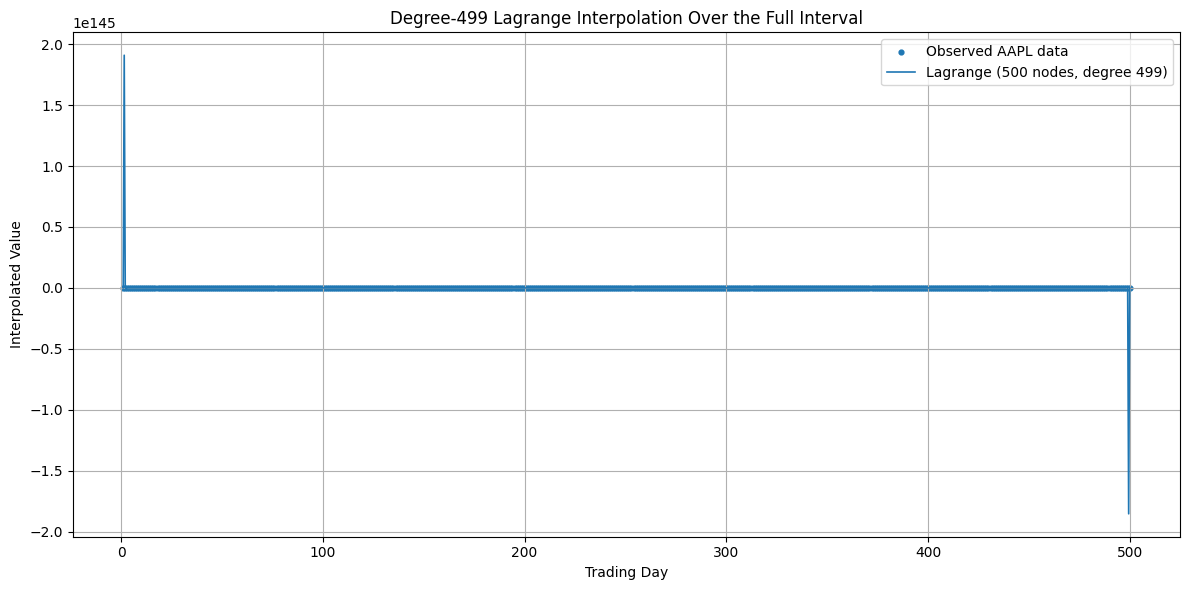

In [62]:
# Dense grid between the 500 interpolation nodes
x_dense = np.linspace(1, 500, 1000)

y_dense = np.array([
    numerical_lagrange(x_nodes, y_nodes, x_val)
    for x_val in x_dense
])

plt.figure(figsize=(12, 6))

# Observed AAPL data
plt.scatter(
    x,
    y,
    s=12,
    label="Observed AAPL data"
)

# Degree-499 Lagrange polynomial
plt.plot(
    x_dense,
    y_dense,
    linewidth=1.2,
    label="Lagrange (500 nodes, degree 499)"
)

plt.xlabel("Trading Day")
plt.ylabel("Interpolated Value")
plt.title("Degree-499 Lagrange Interpolation Over the Full Interval")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

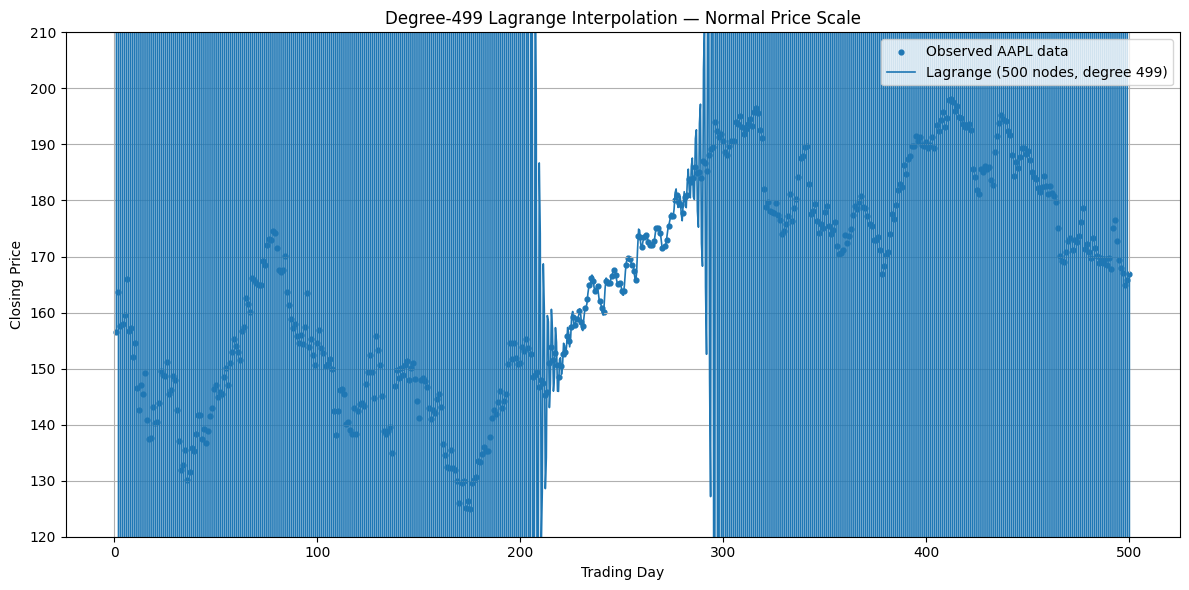

In [63]:
plt.figure(figsize=(12, 6))

plt.scatter(
    x,
    y,
    s=12,
    label="Observed AAPL data"
)

plt.plot(
    x_dense,
    y_dense,
    linewidth=1.2,
    label="Lagrange (500 nodes, degree 499)"
)

plt.ylim(120, 210)

plt.xlabel("Trading Day")
plt.ylabel("Closing Price")
plt.title("Degree-499 Lagrange Interpolation — Normal Price Scale")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [31]:
# Display the measured computation times
timing_table = pd.DataFrame({
    "Nodes": node_counts,
    "Degree": [n - 1 for n in node_counts],
    "Time (seconds)": [timings[n] for n in node_counts]
})

timing_table


,Nodes,Degree,Time (seconds)
0,5,4,0.002232
1,10,9,0.007650
2,20,19,0.031017
3,50,49,0.117397
4,100,99,0.460057
5,250,249,3.016739
6,500,499,12.045323


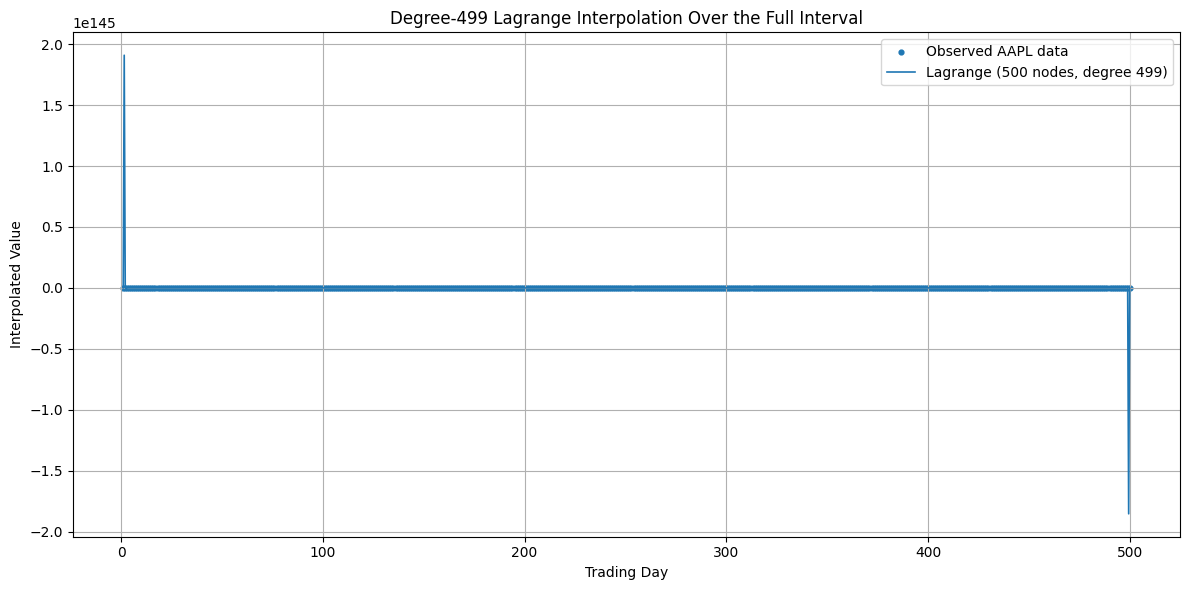

In [60]:
# Dense grid between the 500 interpolation nodes
x_dense = np.linspace(1, 500, 1000)

y_dense = np.array([
    numerical_lagrange(x_nodes, y_nodes, x_val)
    for x_val in x_dense
])

plt.figure(figsize=(12, 6))

# Observed AAPL data
plt.scatter(
    x,
    y,
    s=12,
    label="Observed AAPL data"
)

# Degree-499 Lagrange polynomial
plt.plot(
    x_dense,
    y_dense,
    linewidth=1.2,
    label="Lagrange (500 nodes, degree 499)"
)

plt.xlabel("Trading Day")
plt.ylabel("Interpolated Value")
plt.title("Degree-499 Lagrange Interpolation Over the Full Interval")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

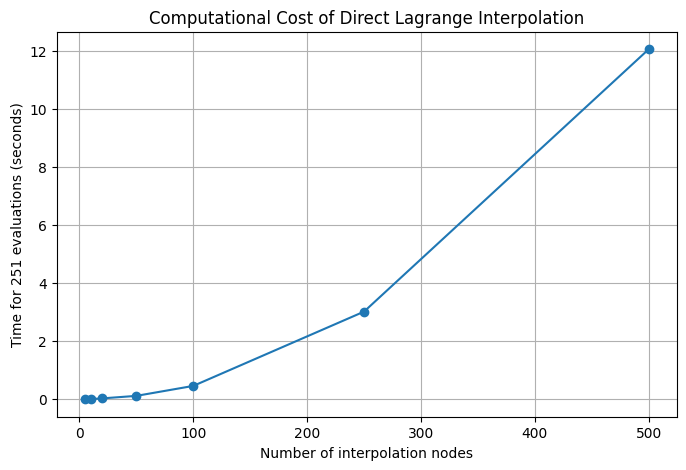

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(
    node_counts,
    [timings[n] for n in node_counts],
    marker="o"
)

plt.xlabel("Number of interpolation nodes")
plt.ylabel("Time for 251 evaluations (seconds)")
plt.title("Computational Cost of Direct Lagrange Interpolation")
plt.grid()
plt.show()


In [16]:
from scipy.interpolate import BarycentricInterpolator

node_counts = [5, 10, 20, 50, 100, 250, 500]

interpolated_results = {}

for n in node_counts:
    # Select n equally spaced indices from the 500 observations
    indices = np.linspace(0, 499, n, dtype=int)

    x_nodes = x[indices]
    y_nodes = y[indices]

    # Construct Lagrange interpolant
    interpolator = BarycentricInterpolator(x_nodes, y_nodes)

    # Evaluate over all 500 days
    y_interp = interpolator(x)

    interpolated_results[n] = y_interp